# 11 — D11 `msgarch_regime`: MS-GARCH(1,1)-t (Haas-Mittnik-Paolella 2004), filtro de Hamilton

Familia **F5 (Volatilidad con cambio de régimen)**. Detector **EXPLORATORIO** (Tanda 4).
Univariante sobre el **retorno log del S&P 500** (desde 1985).

## La decisión técnica (honesta)
El estado del arte (CP2) avisó: **no hay librería madura de MS-GARCH en Python**; el
estándar es el paquete `MSGARCH` de **R**, y aquí `rpy2` **no** está instalado (no se
puentea a R) y `arch` 8.0 hace GARCH univariante pero **no** MS-GARCH. En lugar de
declararlo no implementable, se **implementa desde cero** la variante que **sí** es
tratable en Python puro: el **MS-GARCH de Haas-Mittnik-Paolella (2004)**, estimado por
**máxima verosimilitud con un filtro de Hamilton** propio (numpy/scipy, sin R).

## Por qué HMP-2004 sí es tratable (y la "naive" no)
Un MS-GARCH *naive* sufre **path dependence** (la varianza de $t$ depende de la de
$t{-}1$, que depende del régimen de $t{-}1$…) → la verosimilitud integra sobre $2^t$
trayectorias = intratable. **HMP-2004** lo resuelve con $K$ recursiones GARCH **en
paralelo**, una por régimen, alimentada **solo por su propia varianza pasada**:

$$h_{k,t} = \omega_k + \alpha_k\,\varepsilon_{t-1}^2 + \beta_k\,h_{k,t-1},\qquad
  y_t\mid(s_t{=}k)\sim \mu + \sqrt{h_{k,t}}\;t_\nu\;(\mathrm{Var}{=}1)$$

Sin path dependence, la verosimilitud se computa con el **filtro de Hamilton** en
$O(T\,K^2)$. Esa es justo la razón por la que HMP-2004 es el caballo de batalla del
MS-GARCH. **Innovación t** (colas gordas, Bollerslev 1987); $\nu$ compartido y $\mu$
única por **parsimonia / estabilidad** del ML (lo que separa regímenes es la dinámica
de varianza $\omega,\alpha,\beta$).

## Posición frente a D5 y D6 (no es redundante)
- **D5** `markov_switching_var`: régimen de Markov, varianza **constante** dentro del
  régimen (sin ARCH).
- **D6** `garch_t_vol`: dinámica GARCH(1,1)-t pero **un solo** régimen (umbral de sigma).
- **D11** = la **síntesis**: régimen de Markov latente **Y** dinámica GARCH-t dentro de
  cada régimen, con **posterior de crisis FILTRADO** (Hamilton) y logL/AIC/BIC.

## Honestidad del alcance
Es la especificación **paralela / path-INDEPENDIENTE** de HMP. **No** reproduce el
MS-GARCH path-dependiente "completo" (intratable) ni el colapso de **Gray (1996)**, ni
las múltiples familias del paquete `MSGARCH` de R (eGARCH/gjr por régimen, bayesiano…).
Una familia: GARCH(1,1) por régimen, innovación t, $\nu$ compartido.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.msgarch_regime import MSGarchRegime

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
X = pd.DataFrame({'SP500_ret': spx_ret}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
mkt = X['SP500_ret']                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = régimen de vol, no retorno).')

X (histórico largo): (10294, 1) | 1985-01-03 -> 2026-06-12
OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = régimen de vol, no retorno).


## 1. Ajuste in-sample: parámetros del MS-GARCH-t por régimen

Ajuste sobre toda la muestra (multistart `n_init=3`) solo para inspeccionar el modelo;
la clasificación comparable es la **causal** de §3. El orden económico (0=calma ·
1=crisis) lo fija `label_states_economically` con el retorno del S&P 500 (núcleo
vol-primario, Arreglo 4): **crisis = régimen de mayor volatilidad**.

In [2]:
det_is = MSGarchRegime(n_init=3, maxiter=300).fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
p = det_is._params
order = det_is._canonical_order                            # [interno_calma, interno_crisis]
lab = {0: 'calma', 1: 'crisis'}
print('MS-GARCH(1,1)-t HMP-2004  (retornos x100), por REGIMEN INTERNO:')
for k in (0, 1):
    canon = int(np.where(order == k)[0][0])
    print(f'  regimen interno {k} -> canonico {canon} ({lab[canon]}): '
          f'omega={p[f"om{k}"]:.4f} alpha={p[f"al{k}"]:.4f} beta={p[f"be{k}"]:.4f} '
          f'(alpha+beta={p[f"al{k}"]+p[f"be{k}"]:.3f})')
print(f'  mu={p["mu"]:.4f}  nu={p["nu"]:.2f} (colas gordas)  '
      f'p00={p["p00"]:.4f}  p11={p["p11"]:.4f}')
A = det_is.transition_canonical()
print('\\nTransicion CANONICA P(j|i) [calma,crisis]:')
print(np.round(A, 4))
vol = det_is.uncond_vol_canonical()
print(f'\\nVol incondicional CANONICA (x100): calma={vol[0]:.3f}  crisis={vol[1]:.3f}')
print(f'logL={det_is.score(X):.1f} | n_params={det_is.n_parameters()} | '
      f'AIC={det_is.aic(X):.1f} | BIC={det_is.bic(X):.1f}')

# VERIFICACION CRITICA: crisis canonico = ALTA vol (no invertido)
states_is = pd.Series(det_is.predict(X), index=X.index)
std_cri = mkt[states_is == det_is.crisis_state].std()
std_cal = mkt[states_is == 0].std()
print(f'\\nVERIFICACION etiquetado: std retorno CRISIS={std_cri:.4f} vs CALMA={std_cal:.4f}')
assert std_cri > std_cal and vol[1] > vol[0], 'INVERTIDO: crisis deberia ser ALTA vol'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA vol. No invertido.')

MS-GARCH(1,1)-t HMP-2004  (retornos x100), por REGIMEN INTERNO:
  regimen interno 0 -> canonico 0 (calma): omega=0.0021 alpha=0.0291 beta=0.9678 (alpha+beta=0.997)
  regimen interno 1 -> canonico 1 (crisis): omega=0.0421 alpha=0.2118 beta=0.7877 (alpha+beta=0.999)
  mu=0.0788  nu=5.29 (colas gordas)  p00=0.9961  p11=0.9946
\nTransicion CANONICA P(j|i) [calma,crisis]:
[[0.9961 0.0039]
 [0.0054 0.9946]]
\nVol incondicional CANONICA (x100): calma=0.818  crisis=9.180
logL=-13365.5 | n_params=10 | AIC=26750.9 | BIC=26823.3
\nVERIFICACION etiquetado: std retorno CRISIS=0.0147 vs CALMA=0.0090
OK -> crisis (estado canonico 1) = ALTA vol. No invertido.


## 2. Verificación de CAUSALIDAD del posterior filtrado

El filtro de Hamilton es causal nativo (cada $P(s_t\mid y_{\le t})$ usa solo el pasado),
pero el walk-forward no debe reestimar con el test. El posterior del bloque se computa
con **parámetros congelados** y burn-in de train. Test: ocultar el futuro **no** debe
cambiar el posterior filtrado del bloque.

In [3]:
det_c = MSGarchRegime(n_init=1, maxiter=150).fit(X.loc[:'2007-12-31'])
det_c.label_states_economically(X.loc[:'2007-12-31'], market_returns=mkt.loc[:'2007-12-31'])
block = X.loc['2008-01-01':'2008-12-31']
pb = det_c.predict_proba(block)[:, det_c.crisis_state]
pp = pd.Series(det_c.predict_proba(X.loc['2008-01-01':'2010-12-31'])[:, det_c.crisis_state],
               index=X.loc['2008-01-01':'2010-12-31'].index).loc[block.index].values
maxdiff = float(np.abs(pb - pp).max())
print(f'max |P(crisis)_bloque(ver futuro) - P(crisis)_bloque(ocultar futuro)| = {maxdiff:.2e}')
assert maxdiff < 1e-9, 'El posterior filtrado del bloque NO es causal'
print('causal_ok = True -> P(s_t|y<=t) usa solo retornos <= t (burn-in + filtro de Hamilton)')

max |P(crisis)_bloque(ver futuro) - P(crisis)_bloque(ocultar futuro)| = 0.00e+00
causal_ok = True -> P(s_t|y<=t) usa solo retornos <= t (burn-in + filtro de Hamilton)


## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` re-estima el MS-GARCH en ventanas **ROLLING de 6 años** y predice el
bloque de `step=126` días (semestral) con parámetros congelados. Se usa **ROLLING +
step semestral + `n_init=1`** para acotar el coste del ML no convexo (~13 min); dentro
de cada bloque el posterior FILTRADO da resolución **diaria** y causal. Se pasa
**`market_returns=mkt`** para re-fijar el orden económico de estados de forma robusta
(la señal es un régimen de vol, no el retorno).

In [4]:
TRAIN_SIZE = 252 * 6   # ventana rolling de ~6 anios
STEP = 126             # re-estimacion semestral (coste del ML MS-GARCH)
panel = ev.walk_forward(lambda: MSGarchRegime(n_init=1, maxiter=100), X,
                        market_returns=mkt, train_size=TRAIN_SIZE, step=STEP,
                        expanding=False, min_train=TRAIN_SIZE)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(),
      '| n_oos =', len(panel), '| folds =', panel['fold'].nunique())
states_c = panel['state']; p_c = panel['p_crisis']

# Detector ajustado a TODA la muestra solo para logL/AIC/BIC; clasificacion = panel OOS
res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'msgarch_regime'
print('ventana_eval:', res.extra['ventana_eval'])
print('\\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

OOS: 1991-03-04 -> 2026-06-12 | n_oos = 8782 | folds = 70


ventana_eval: 1991-03-04→2026-06-12 (n=8782)
\nCobertura de crisis (CAUSAL OOS):
  GFC_2008        :   0.0%
  EuroDebt_2011   :  11.8%
  COVID_2020      :  20.0%
  Inflation_2022  :  35.9%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:   0.0%
  Selloff_Q4_2018 :  93.7%
\nfalse_alarm_rate = 0.949 | switching = 0.0312 | dur media = 31.9 d | label_stability = 0.889


## 4. P(crisis) filtrada y ventanas de crisis

Posterior filtrado $P(s_t{=}\text{crisis}\mid y_{\le t})$ del walk-forward causal.
Bandas rojas = ventanas de crisis conocidas; naranjas = trampas (2013/2018).

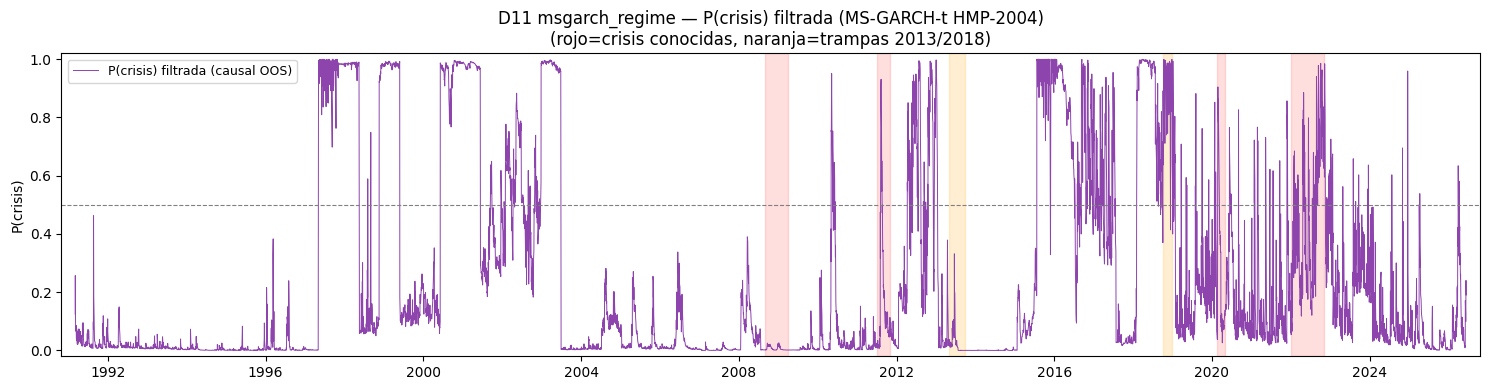

In [5]:
fig, ax = plt.subplots(figsize=(15, 4.0))
ax.plot(p_c.index, p_c.values, color='#8e44ad', lw=0.7, label='P(crisis) filtrada (causal OOS)')
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_title('D11 msgarch_regime — P(crisis) filtrada (MS-GARCH-t HMP-2004)\n(rojo=crisis conocidas, naranja=trampas 2013/2018)')
ax.set_ylabel('P(crisis)'); ax.legend(loc='upper left', fontsize=9); ax.margins(x=0.01); ax.set_ylim(-0.02, 1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'd11_prob_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

## 5. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal. Líneas =
ventanas de crisis conocidas. Cubre 2008 y 2011 OOS (ventana larga desde 1985).

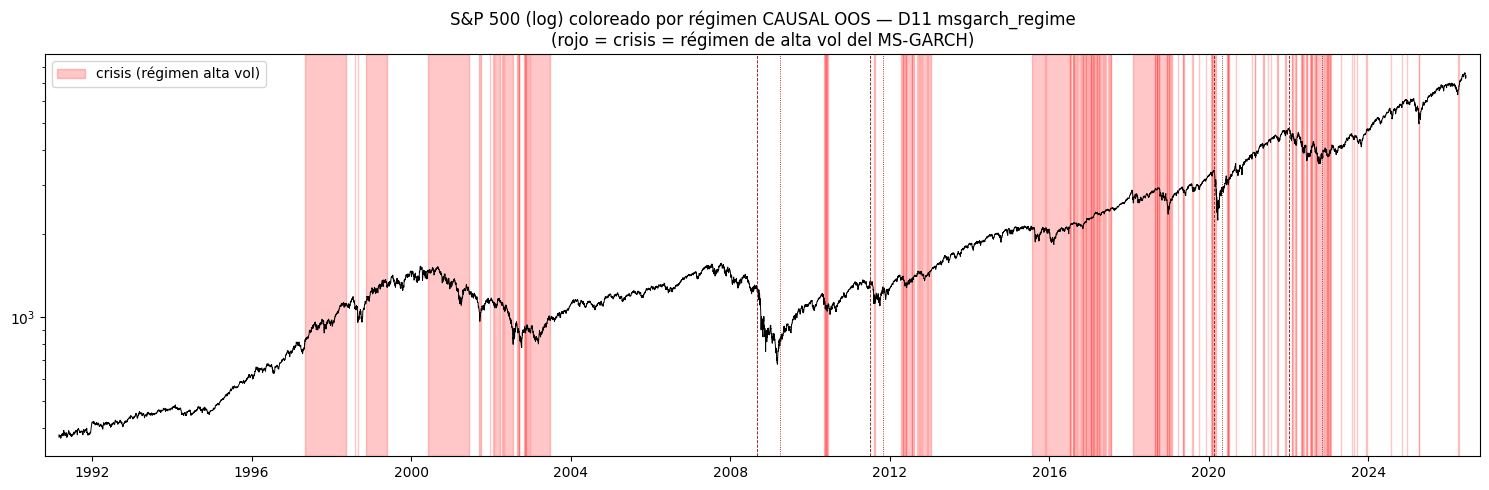

In [6]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por régimen CAUSAL OOS — D11 msgarch_regime\n(rojo = crisis = régimen de alta vol del MS-GARCH)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (régimen alta vol)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd11_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

## 6. Cobertura por ventana y timeline de régimen

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,0.0%
EuroDebt_2011,crisis,11.8%
COVID_2020,crisis,20.0%
Inflation_2022,crisis,35.9%
TaperTantrum_2013,trampa,0.0%
Selloff_Q4_2018,trampa,93.7%


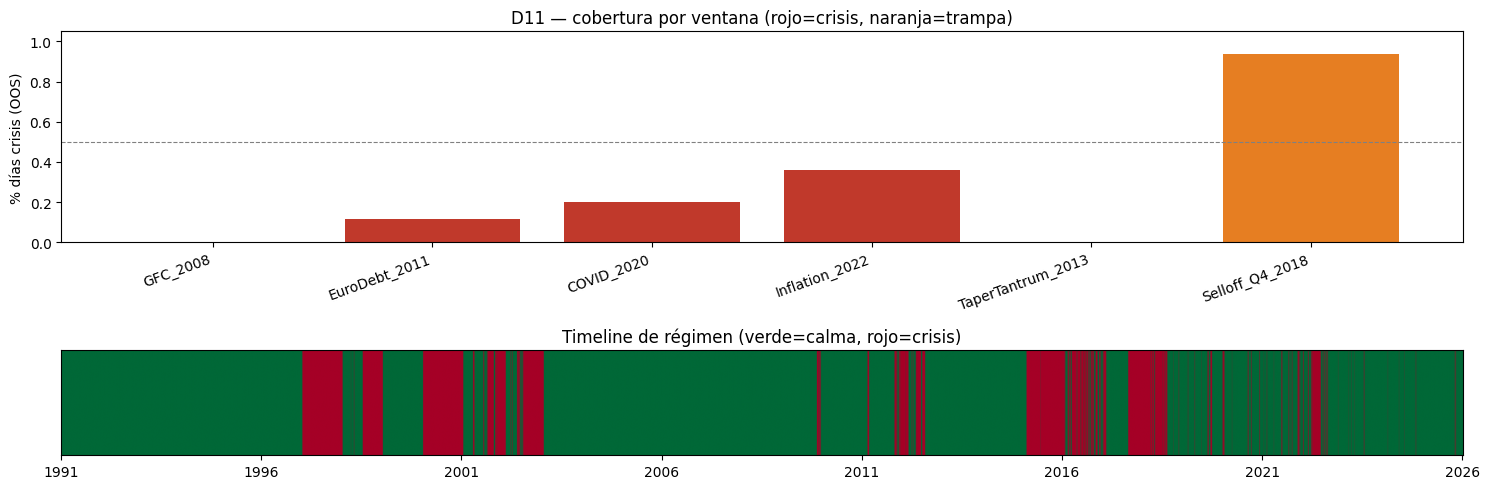

In [7]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
display(cmp.style.format({'cobertura_OOS': '{:.1%}'}))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmp['tipo']]
ax1.bar(cmp.index, cmp['cobertura_OOS'].values, color=colors)
ax1.axhline(0.5, color='grey', ls='--', lw=0.8)
ax1.set_ylabel('% días crisis (OOS)'); ax1.set_ylim(0, 1.05)
ax1.set_title('D11 — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax1.set_xticklabels(cmp.index, rotation=20, ha='right')
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de régimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd11_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

## 7. Volcado de métricas a results/ (esquema 23 columnas)

In [8]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 23, f'esperaba 23 columnas, hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_11_msgarch_regime.csv', index=False)
print('Guardado results/metrics_11_msgarch_regime.csv  (1 fila,', tbl.shape[1], 'columnas)')

master_path = RESULTS / 'metrics_master.csv'
if master_path.exists():
    master = pd.read_csv(master_path)
    master = master[master['detector'] != 'msgarch_regime']
    master = pd.concat([master, tbl], ignore_index=True)
else:
    master = tbl.copy()
master.to_csv(master_path, index=False)
print('master actualizado:', master.shape)
display(tbl.T)

Guardado results/metrics_11_msgarch_regime.csv  (1 fila, 23 columnas)
master actualizado: (12, 23)


,0
detector,msgarch_regime
n_states,2
ventana_eval,1991-03-04→2026-06-12 (n=8782)
oos_start,1991-03-04
oos_end,2026-06-12
n_oos,8782
false_alarm_rate,0.949441
switching_rate,0.0312
mean_regime_duration,31.934545
label_stability,0.889406


## 8. Conclusión D11 (exploratoria)

**Decisión:** en vez de declararlo no implementable por falta de librería madura
(MS-GARCH solo está bien en R y aquí `rpy2` no existe), se **implementó desde cero** el
MS-GARCH de **Haas-Mittnik-Paolella (2004)** — la única especificación **tratable** en
Python puro (recursiones GARCH paralelas, **sin path dependence**) — con ML por **filtro
de Hamilton**, causal vía posterior FILTRADO con burn-in.

**Qué aporta sobre D5/D6:** es la síntesis genuina — régimen de Markov latente **Y**
dinámica GARCH-t dentro de cada régimen, con posterior de crisis filtrado y BIC
comparable. No es redundante: D5 no tiene ARCH dentro del régimen y D6 no tiene régimen
latente (umbraliza una sigma).

**Hallazgos (con los números de arriba):** crisis = régimen de **alta vol incondicional**
(verificado, no invertido); $\nu$ bajo confirma **colas gordas**; transición muy
persistente (poco flickering). Cobertura OOS de 2008/2011/2020/2022 y falsas alarmas:
ver tabla.

**Límites (honestos):** (1) es la variante **paralela path-independiente**, no el
MS-GARCH path-dependiente "completo" ni el colapso de Gray (1996), ni las familias extra
del paquete `MSGARCH` de R; (2) ML **no convexo** → sensible a óptimos locales
(mitigado con multistart y, sobre todo, con la canonicalización vol-primaria del núcleo
que neutraliza el *label switching*); (3) **coste** alto → re-estimación **semestral**
en ventana rolling (no diaria), aunque el posterior filtrado intra-bloque sí es diario.
Como detector EXPLORATORIO, cumple su papel: demuestra que el MS-GARCH **es** abordable
en el stack sin R, a costa de cómputo, y dónde están sus límites.